#  NYC Datenbereinigung, erste einfache EDA und Regression

Datensatz von https://insideairbnb.com/get-the-data/

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

In [26]:
import sys
import os

# Definiert den relativen Pfad zum 'src' Ordner
# .. = Ein Ordner hoch zum Projekt-Root
# /src = Dann in den Ordner src
src_path = os.path.join(os.getcwd(), '..', 'src')

# Fügt diesen Pfad dem Python-Suchpfad hinzu
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"✅ src-Ordner temporär zum Suchpfad hinzugefügt: {src_path}")

✅ src-Ordner temporär zum Suchpfad hinzugefügt: c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\notebooks\..\src


In [27]:
df = pd.read_csv("../data/raw/listings_NYC.csv")

In [28]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,🪴XL dojo 🌾 shared green yogi palace apt 🌿,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


In [29]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.611100e+04,3.611100e+04,3.611100e+04,34944.000000,34944.000000,36111.000000,36111.000000,36111.000000,21700.000000,30162.000000,...,24922.000000,24909.000000,24917.000000,24907.000000,24907.000000,36111.000000,36111.000000,36111.000000,36111.000000,24923.000000
mean,4.667906e+17,2.025100e+13,1.756195e+08,112.264652,194.007068,40.728253,-73.947350,2.733239,1.192788,1.386016,...,4.655356,4.833791,4.821406,4.743204,4.634118,67.455152,48.661793,17.957824,0.052532,0.821178
std,5.448721e+17,3.906304e-03,1.945624e+08,592.417347,900.407345,0.056269,0.054995,1.866400,0.548018,0.944931,...,0.510746,0.384702,0.425933,0.399600,0.504016,215.678813,204.537592,79.015677,0.775728,1.916104
min,2.595000e+03,2.025100e+13,1.678000e+03,1.000000,1.000000,40.500366,-74.251907,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.159416e+07,2.025100e+13,1.795864e+07,1.000000,1.000000,40.688260,-73.983560,2.000000,1.000000,1.000000,...,4.540000,4.820000,4.820000,4.660000,4.520000,1.000000,0.000000,0.000000,0.000000,0.070000
50%,5.095308e+07,2.025100e+13,8.832602e+07,2.000000,3.000000,40.725960,-73.955000,2.000000,1.000000,1.000000,...,4.810000,4.950000,4.960000,4.860000,4.760000,2.000000,1.000000,1.000000,0.000000,0.250000
75%,9.747695e+17,2.025100e+13,3.107737e+08,8.000000,12.000000,40.762120,-73.928118,4.000000,1.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.940000,9.000000,2.000000,2.000000,0.000000,0.900000
max,1.521848e+18,2.025100e+13,7.214431e+08,5478.000000,9764.000000,40.912017,-73.711822,16.000000,15.500000,16.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1148.000000,1148.000000,567.000000,20.000000,122.760000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   listing_url                                   36111 non-null  object 
 2   scrape_id                                     36111 non-null  int64  
 3   last_scraped                                  36111 non-null  object 
 4   source                                        36111 non-null  object 
 5   name                                          36109 non-null  object 
 6   description                                   35153 non-null  object 
 7   neighborhood_overview                         18704 non-null  object 
 8   picture_url                                   36111 non-null  object 
 9   host_id                                       36111 non-null 

## Feature Engineering: Distance to center als neue Spalte

Ausgangspunkt: latitude, longitude   
Ziel: Abstand zum Times Square (als Center von NYC messen)

In [32]:
# 1. Imports aus der src-Datei
# Stellen Sie sicher, dass die Pfad-Anpassung am Anfang des Notebooks ausgeführt wurde!
from haversine_distanz import calculate_distance, get_city_center_coords

# 2. DEFINITION DES ZENTRUMS (Dynamischer Abruf)
TARGET_CITY = "New York City, USA" # Beispiel-Stadt
print(f"Suche Koordinaten für: {TARGET_CITY}...")

try:
    center_lat, center_lon = get_city_center_coords(TARGET_CITY)
    print(f"✅ Gefunden: LAT={center_lat}, LON={center_lon}")
except Exception as e:
    print(f"❌ Fehler beim Abruf: {e}")
    # Optional: Fallback auf Default-Werte, falls Abruf fehlschlägt
    # center_lat, center_lon = 40.7580, -73.9855


# 3. ANWENDUNG DER DISTANZBERECHNUNG
if center_lat is not None:
    df['distance_to_center'] = calculate_distance(
        df['latitude'], 
        df['longitude'], 
        center_lat, 
        center_lon
    )

    print("\n✅ Neue Spalte 'distance_to_center' erfolgreich hinzugefügt.")
    print(df[['latitude', 'longitude', 'distance_to_center']].head())

Suche Koordinaten für: New York City, USA...
✅ Gefunden: LAT=40.7127281, LON=-74.0060152


NameError: name 'lon2_rad' is not defined

In [72]:
from geopy.geocoders import Nominatim
import pandas as pd
import os # Immer noch nützlich für Dateipfad-Handhabung

# Initialisiere den Geocoder (NUR EINMAL ausführen!)
geolocator = Nominatim(user_agent="nyc_airbnb_analysis_project")

def get_city_once(latitude, longitude):
    """
    Führt Reverse Geocoding FÜR EINE EINZIGE KOORDINATE durch, 
    um den relevanten Stadtnamen/Borough zu ermitteln.
    """
    try:
        # Hier MÜSSEN wir KEINEN RateLimiter verwenden, da wir nur eine Abfrage machen.
        location = geolocator.reverse((latitude, longitude), exactly_one=True)
        
        if location and location.raw and 'address' in location.raw:
            address = location.raw['address']
            
            # Da wir in NYC sind, suchen wir nach dem Borough, der oft als 'city' oder 'suburb' erkannt wird
            city = address.get('suburb') or address.get('city') or address.get('borough') or address.get('town')
            
            if city:
                return city.upper()
            
        return "UNKNOWN"
        
    except Exception as e:
        # Falls die Anfrage fehlschlägt
        print(f"FEHLER beim Geocoding der ersten Zeile: {e}")
        return "ERROR_API"

In [73]:
df[['distance_to_center', 'latitude', 'longitude', 'price', 'instant_bookable', 'room_type']].head()

,distance_to_center,latitude,longitude,price,instant_bookable,room_type
0,8.364948,40.74698,-73.91763,$66.00,f,Private room
1,1.581587,40.72314,-73.99323,NaN,t,Private room
2,7.412160,40.64607,-74.00552,NaN,f,Private room
3,4.972334,40.68370,-73.96115,NaN,t,Entire home/apt
4,2.192270,40.72147,-73.98270,$76.00,f,Private room


## Reduktion der Spalten

In [74]:
SPALTEN_REDUZIERT = [
    'accommodates',
    'price',
    'host_total_listings_count',
    'review_scores_rating', 
    'latitude', 
    'longitude', 
    'availability_365',
    'distance_to_center',
    'instant_bookable',
    'room_type'
] 

In [75]:
df_simple = df[SPALTEN_REDUZIERT].copy()

In [76]:
df_simple.head()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365,distance_to_center,instant_bookable,room_type
0,1,$66.00,3.0,4.81,40.74698,-73.91763,77,8.364948,f,Private room
1,2,NaN,1.0,NaN,40.72314,-73.99323,0,1.581587,t,Private room
2,1,NaN,1.0,5.00,40.64607,-74.00552,0,7.412160,f,Private room
3,1,NaN,3.0,5.00,40.68370,-73.96115,0,4.972334,t,Entire home/apt
4,1,$76.00,16.0,4.95,40.72147,-73.98270,168,2.192270,f,Private room


## Löschung aller Zeilen ohne Preis

In [77]:
df_clean = df_simple.dropna(subset=['price']).copy()
print(f"Zeilen nach der Preislöschung: {len(df_clean)}")

Zeilen nach der Preislöschung: 21328


In [78]:
# 1. Entfernen von Währungszeichen ($), Kommas (,) und Leerzeichen
df_clean['price'] = df_clean['price'].astype(str).str.replace(r'[$,\s]', '', regex=True)

# 2. Konvertieren zu numerischem Float
# Wichtig: errors='coerce' verwandelt Einträge, die nicht konvertiert werden können (z.B. leere Zellen, 'N/A'), in NaN.
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

In [79]:
df_clean['accommodates'] = df_clean['accommodates'].astype(float)

### Imputation fehlender Werte

In [80]:
IMPUTATIONS_SPALTEN = ['host_total_listings_count', 'review_scores_rating']

for col in IMPUTATIONS_SPALTEN:
    median_wert = df_clean[col].median()
    
    # KORRIGIERT: Keine inplace=True. Das Ergebnis der fillna-Operation 
    # wird direkt der Spalte zugewiesen.
    df_clean[col] = df_clean[col].fillna(median_wert)
    
    print(f"  -> Spalte '{col}': NaNs durch Median ({median_wert:.2f}) ersetzt.")

  -> Spalte 'host_total_listings_count': NaNs durch Median (5.00) ersetzt.
  -> Spalte 'review_scores_rating': NaNs durch Median (4.86) ersetzt.


In [81]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               21328 non-null  float64
 1   price                      21328 non-null  float64
 2   host_total_listings_count  21328 non-null  float64
 3   review_scores_rating       21328 non-null  float64
 4   latitude                   21328 non-null  float64
 5   longitude                  21328 non-null  float64
 6   availability_365           21328 non-null  int64  
 7   distance_to_center         21328 non-null  float64
 8   instant_bookable           21328 non-null  object 
 9   room_type                  21328 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 1.8+ MB


Lückenloser Datensatz liegt vor! 

In [82]:
df_clean.to_csv('listings_short_NYC.csv')

In [83]:
df1=df_clean

## One Hot Encoding: Instant_bookable

In [84]:
from IPython.display import display
display(df1['instant_bookable'].head(20))


0     f
4     f
5     f
7     f
8     f
9     f
10    f
11    f
12    f
14    t
15    f
17    t
20    t
24    t
25    t
27    f
28    f
29    f
32    t
33    f
Name: instant_bookable, dtype: object

In [85]:
print(df1['instant_bookable'].unique())
mapping = {'t': 1, 'f': 0}
# 1. Umwandlung des String-Features in 0 und 1
# Wir überschreiben die alte Spalte (oder erstellen eine neue, das ist sauberer)
df1['is_instant_bookable'] = df1['instant_bookable'].replace(mapping)

# 2. Löschen der alten Spalte (Optional, aber empfohlen)
df1 = df1.drop('instant_bookable', axis=1)

# 3. Überprüfung der neuen Spalte
df1['is_instant_bookable'].value_counts()

['f' 't']


C:\Users\Annette\AppData\Local\Temp\ipykernel_17156\2203128008.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['is_instant_bookable'] = df1['instant_bookable'].replace(mapping)


is_instant_bookable
0    15966
1     5362
Name: count, dtype: int64

### One Hot Encoding für 'room_type'

In [86]:
# Untersucht die Spalte 'room_type'
print("--- Überblick über die vorhandenen Room Types ---")
print(df1['room_type'].value_counts())
print("\n--- Als Prozentsatz ---")
print(df1['room_type'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

--- Überblick über die vorhandenen Room Types ---
room_type
Entire home/apt    11985
Private room        8930
Hotel room           234
Shared room          179
Name: count, dtype: int64

--- Als Prozentsatz ---
room_type
Entire home/apt    56.19%
Private room       41.87%
Hotel room           1.1%
Shared room         0.84%
Name: proportion, dtype: object


In [64]:
## 🎯 SCHRITT 1: ANWENDUNG DES ONE-HOT-ENCODINGS (DUMMIES)

# 1. Anwendung von One-Hot-Encoding auf die Spalte 'room_type'.
# get_dummies entfernt die Originalspalte 'room_type' automatisch und erstellt neue Spalten.
# prefix='room' stellt sicher, dass die neuen Spalten leicht identifizierbar sind.
df = pd.get_dummies(df, columns=['room_type'], prefix='room', dtype=int)


# 2. Überprüfung der neuen Spalten
print("--- Die erzeugten Dummy-Spalten ---")
# Die Ausgabe zeigt nun die vier neuen Spalten in der Spaltenliste:
print(df.filter(regex='^room_').head())

print("\n✅ Die Spalte 'room_type' wurde durch binäre Dummy-Variablen ersetzt.")

# Hinweis: Wenn Sie nun die reduzierte Spaltenliste df_simple erstellen, 
# müssen Sie die vier neuen Spalten hinzufügen und 'room_type' entfernen!

KeyError: "None of [Index(['room_type'], dtype='object')] are in the [columns]"

### EDA

siehe: https://www.youtube.com/watch?v=O2Cw82YR5Bo

In [61]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               21328 non-null  float64
 1   price                      21328 non-null  float64
 2   host_total_listings_count  21328 non-null  float64
 3   review_scores_rating       21328 non-null  float64
 4   latitude                   21328 non-null  float64
 5   longitude                  21328 non-null  float64
 6   availability_365           21328 non-null  int64  
 7   distance_to_center         21328 non-null  float64
 8   room_type                  21328 non-null  object 
 9   is_instant_bookable        21328 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 1.8+ MB


In [63]:
df1.describe()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365,distance_to_center,is_instant_bookable
count,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000,21328.000000
mean,2.868014,680.526819,244.445940,4.769270,40.727018,-73.944055,251.044120,8.455427,0.251407
std,2.021471,4480.453282,1015.854308,0.381238,0.058734,0.060404,106.941151,5.183807,0.433832
min,1.000000,10.000000,1.000000,1.000000,40.500366,-74.251907,0.000000,0.006350,0.000000
25%,2.000000,89.000000,2.000000,4.760000,40.685195,-73.983262,172.000000,4.877343,0.000000
50%,2.000000,154.000000,5.000000,4.860000,40.726895,-73.953500,276.000000,7.460013,0.000000
75%,4.000000,279.000000,22.000000,4.930000,40.763037,-73.922741,347.000000,11.003034,1.000000
max,16.000000,50104.000000,9764.000000,5.000000,40.912017,-73.711822,365.000000,30.952448,1.000000


#### Zielvariable Price

a) Boxplots

<Axes: xlabel='price'>

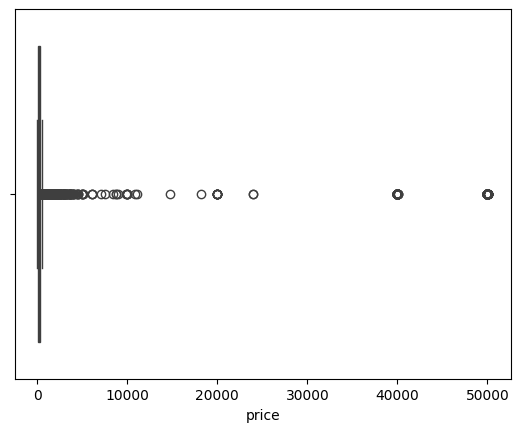

In [151]:
sns.boxplot(x='price', data= df1)

Wenn Sie sich nicht auf einen festen Wert ($1000) festlegen möchten, können Sie auch das 99. Perzentil Ihres eigenen Datensatzes verwenden. Das schließt die extremsten 1% der Ausreißer aus und zeigt 99% der Daten:

99. Perzentil liegt bei: $19514.00


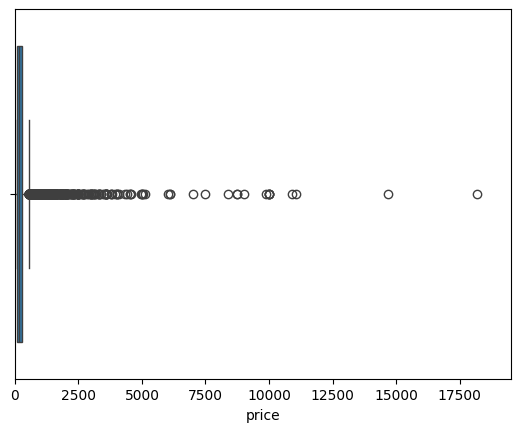

In [152]:
# Berechnung des 99. Perzentils
limit_99 = df1['price'].quantile(0.99)
print(f"99. Perzentil liegt bei: ${limit_99:.2f}") 

# Plot-Befehl mit dem berechneten Limit:
sns.boxplot(x='price', data=df1)
plt.xlim(0, limit_99) 
plt.show()

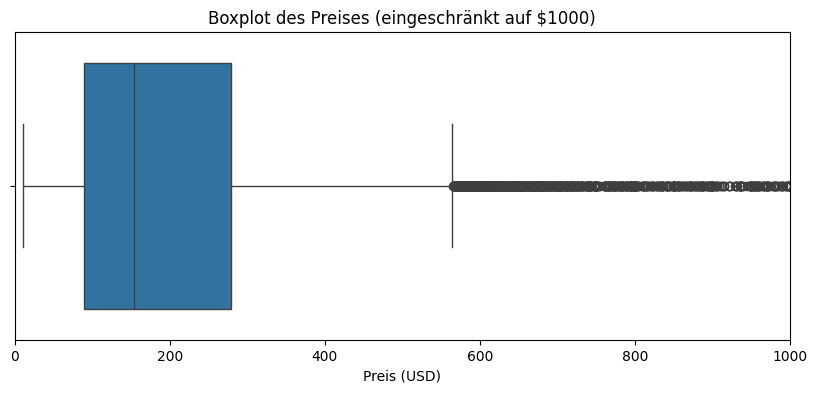

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wir verwenden df_clean, den bereinigten Datensatz
# mit der numerischen 'price' Spalte

plt.figure(figsize=(10, 4))

# 1. Erstellen des Boxplots
sns.boxplot(x='price', data=df_clean)

# 2. EINSCHRÄNKUNG DER X-ACHSE (von 0 bis 1000 USD)
# Dies skaliert das Diagramm neu, um nur diesen Bereich anzuzeigen.
# Wenn Sie den Plot in der Zelle ausführen, wird er so angezeigt.
plt.xlim(0, 1000) 

plt.title('Boxplot des Preises (eingeschränkt auf $1000)')
plt.xlabel('Preis (USD)')
plt.show()

#### Scatterplots

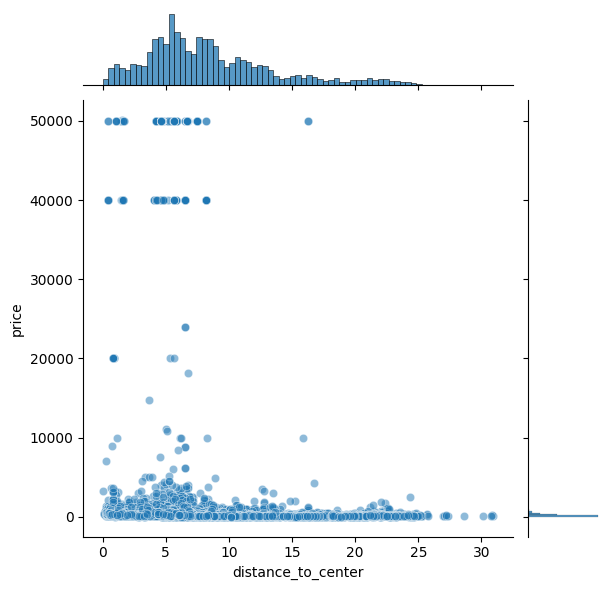

In [154]:
sns.jointplot(x='distance_to_center', y='price', data=df1, alpha=0.5)

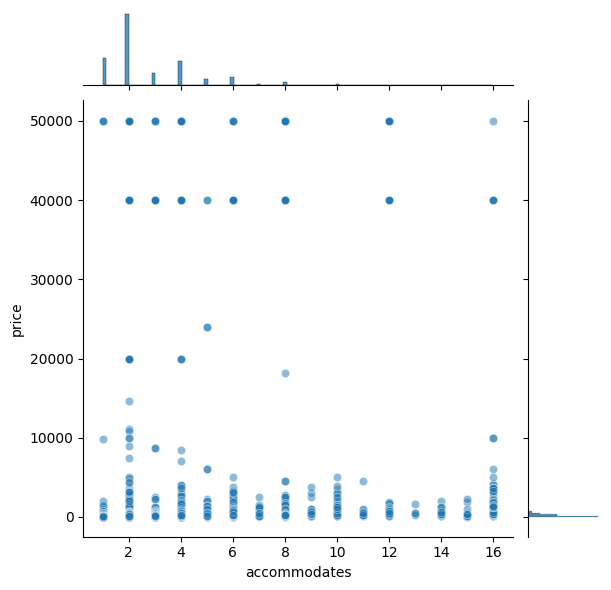

In [155]:
sns.jointplot(x='accommodates', y='price', data=df1, alpha=0.5)

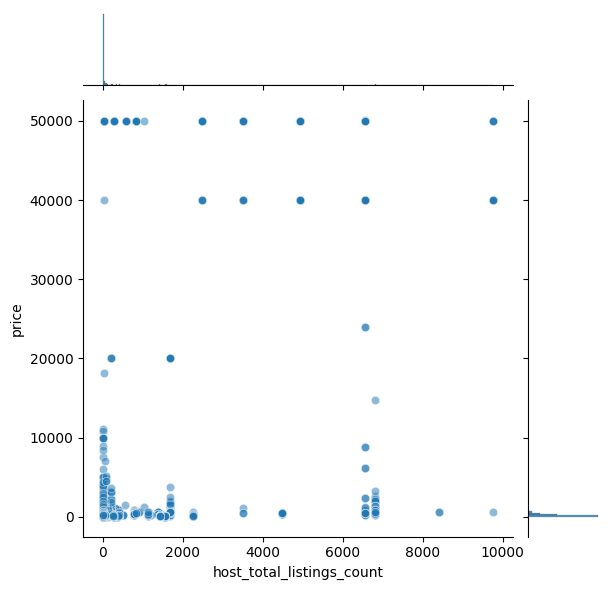

In [156]:
sns.jointplot(x='host_total_listings_count', y='price', data=df1, alpha=0.5)

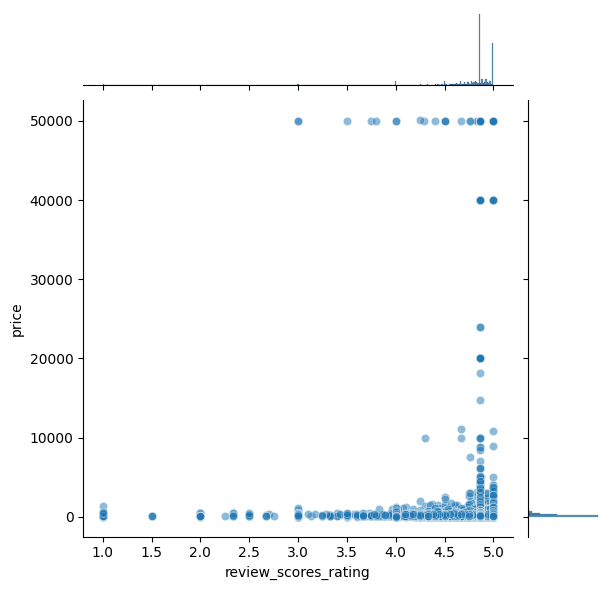

In [157]:

sns.jointplot(x='review_scores_rating', y='price', data=df1, alpha=0.5)

### Zielvariable Price - mit ln-transformation

Erstellen der neuen Spalte 'ln_price':

In [158]:
import numpy as np


df1['ln_price'] = np.log1p(df1['price'])

print("✅ Spalte 'ln_price' erfolgreich erstellt.")
print(df1[['price', 'ln_price']].head())

✅ Spalte 'ln_price' erfolgreich erstellt.
   price  ln_price
0   66.0  4.204693
4   76.0  4.343805
5   97.0  4.584967
7   60.0  4.110874
8  425.0  6.054439


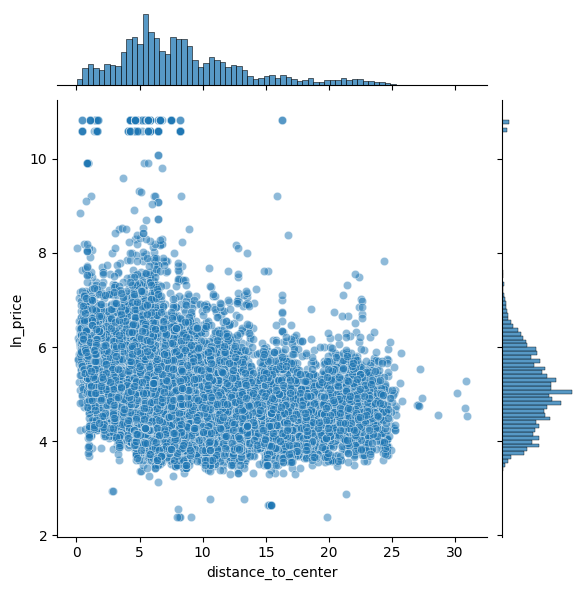

In [159]:
sns.jointplot(x='distance_to_center', y='ln_price', data=df1, alpha=0.5)

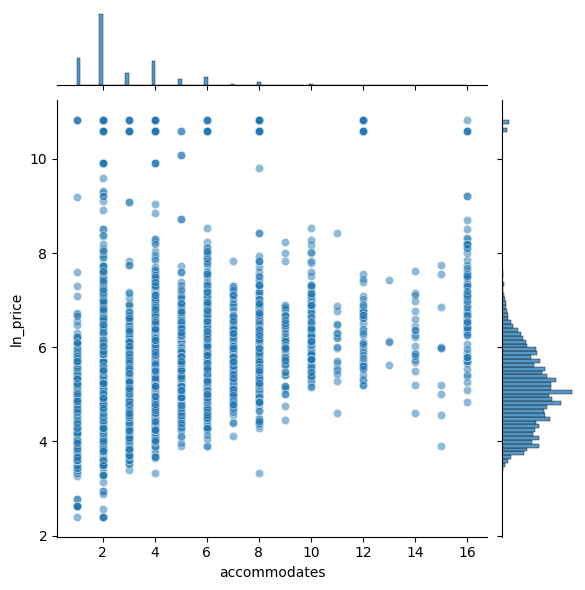

In [160]:
sns.jointplot(x='accommodates', y='ln_price', data=df1, alpha=0.5)

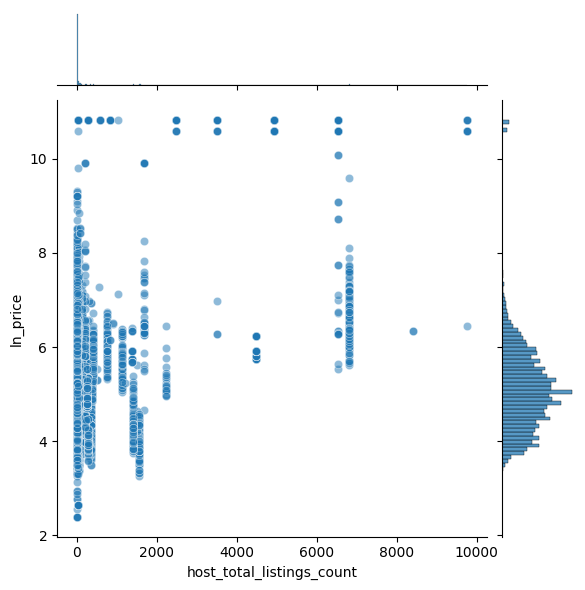

In [161]:
sns.jointplot(x='host_total_listings_count', y='ln_price', data=df1, alpha=0.5)

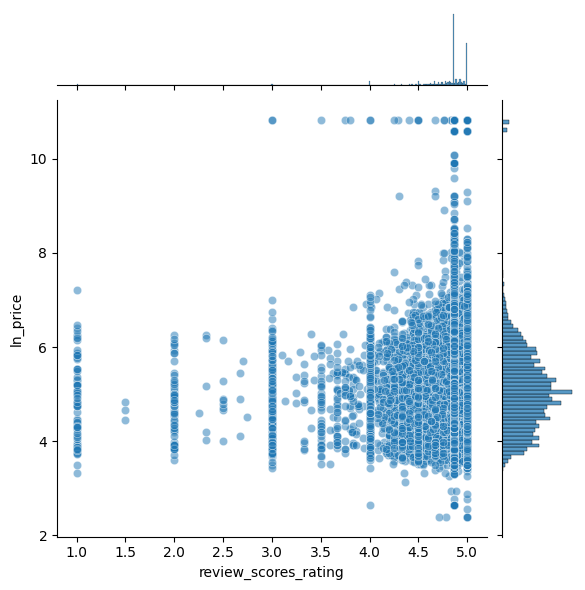

In [162]:
sns.jointplot(x='review_scores_rating', y='ln_price', data=df1, alpha=0.5)

### Gemeinsame Visualisierung von 'price' und 'ln_price'

KeyError: 'ln_price'

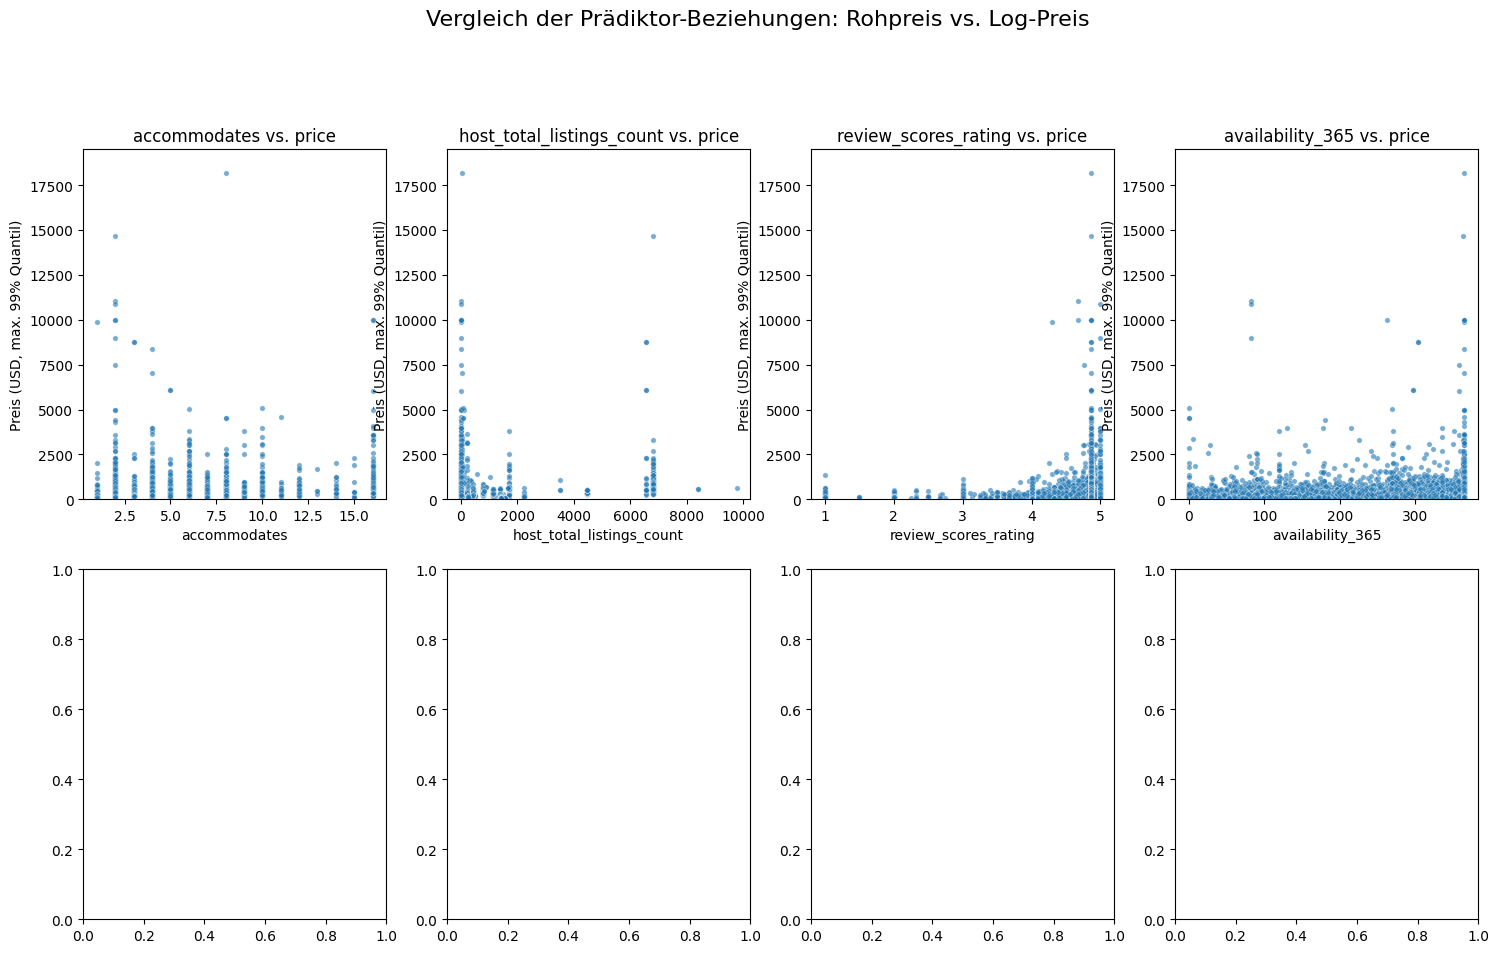

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Nur zur Sicherheit, falls nicht importiert

# Annahme: df_clean enthält die Spalten 'price' und 'ln_price'
PREDICTOR_SPALTEN = ['accommodates', 'host_total_listings_count', 'review_scores_rating', 'availability_365']
TARGET_SPALTEN = ['price', 'ln_price']

# Definition des maximalen Werts für die y-Achse des rohen Preises (zur besseren Sichtbarkeit)
PRICE_LIMIT = df_clean['price'].quantile(0.99)

# Erstellen der großen Figur: 2 Reihen, 3 Spalten (2x3 Grid)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
plt.suptitle('Vergleich der Prädiktor-Beziehungen: Rohpreis vs. Log-Preis', fontsize=16, y=1.02)

# Abflachen des Achsen-Arrays, um es leicht durchlaufen zu können
# axes[0, 0], axes[0, 1], axes[0, 2] = Erste Reihe (price)
# axes[1, 0], axes[1, 1], axes[1, 2] = Zweite Reihe (ln_price)

# Äußere Schleife: Durchläuft die Zielvariablen (Reihen)
for row_index, target in enumerate(TARGET_SPALTEN):
    
    # Innere Schleife: Durchläuft die Prädiktoren (Spalten)
    for col_index, predictor in enumerate(PREDICTOR_SPALTEN):
        
        # Zugriff auf die korrekte Subplot-Position (axes[Reihe, Spalte])
        ax = axes[row_index, col_index]
        
        # Erstellen des Scatterplots
        sns.scatterplot(
            x=df_clean[predictor], 
            y=df_clean[target], 
            ax=ax, 
            alpha=0.6, 
            s=15 # Größe der Punkte
        )
        
        ax.set_title(f'{predictor} vs. {target}')
        ax.set_xlabel(predictor)
        
        # Nur für die obere Reihe (price): Y-Achse auf PRICE_LIMIT begrenzen
        if target == 'price':
            ax.set_ylim(0, PRICE_LIMIT)
            ax.set_ylabel('Preis (USD, max. 99% Quantil)')
        else:
            ax.set_ylabel('Log(1 + Preis)')
            
# Sicherstellen, dass die Plots sich nicht überlappen
plt.tight_layout()
plt.show()

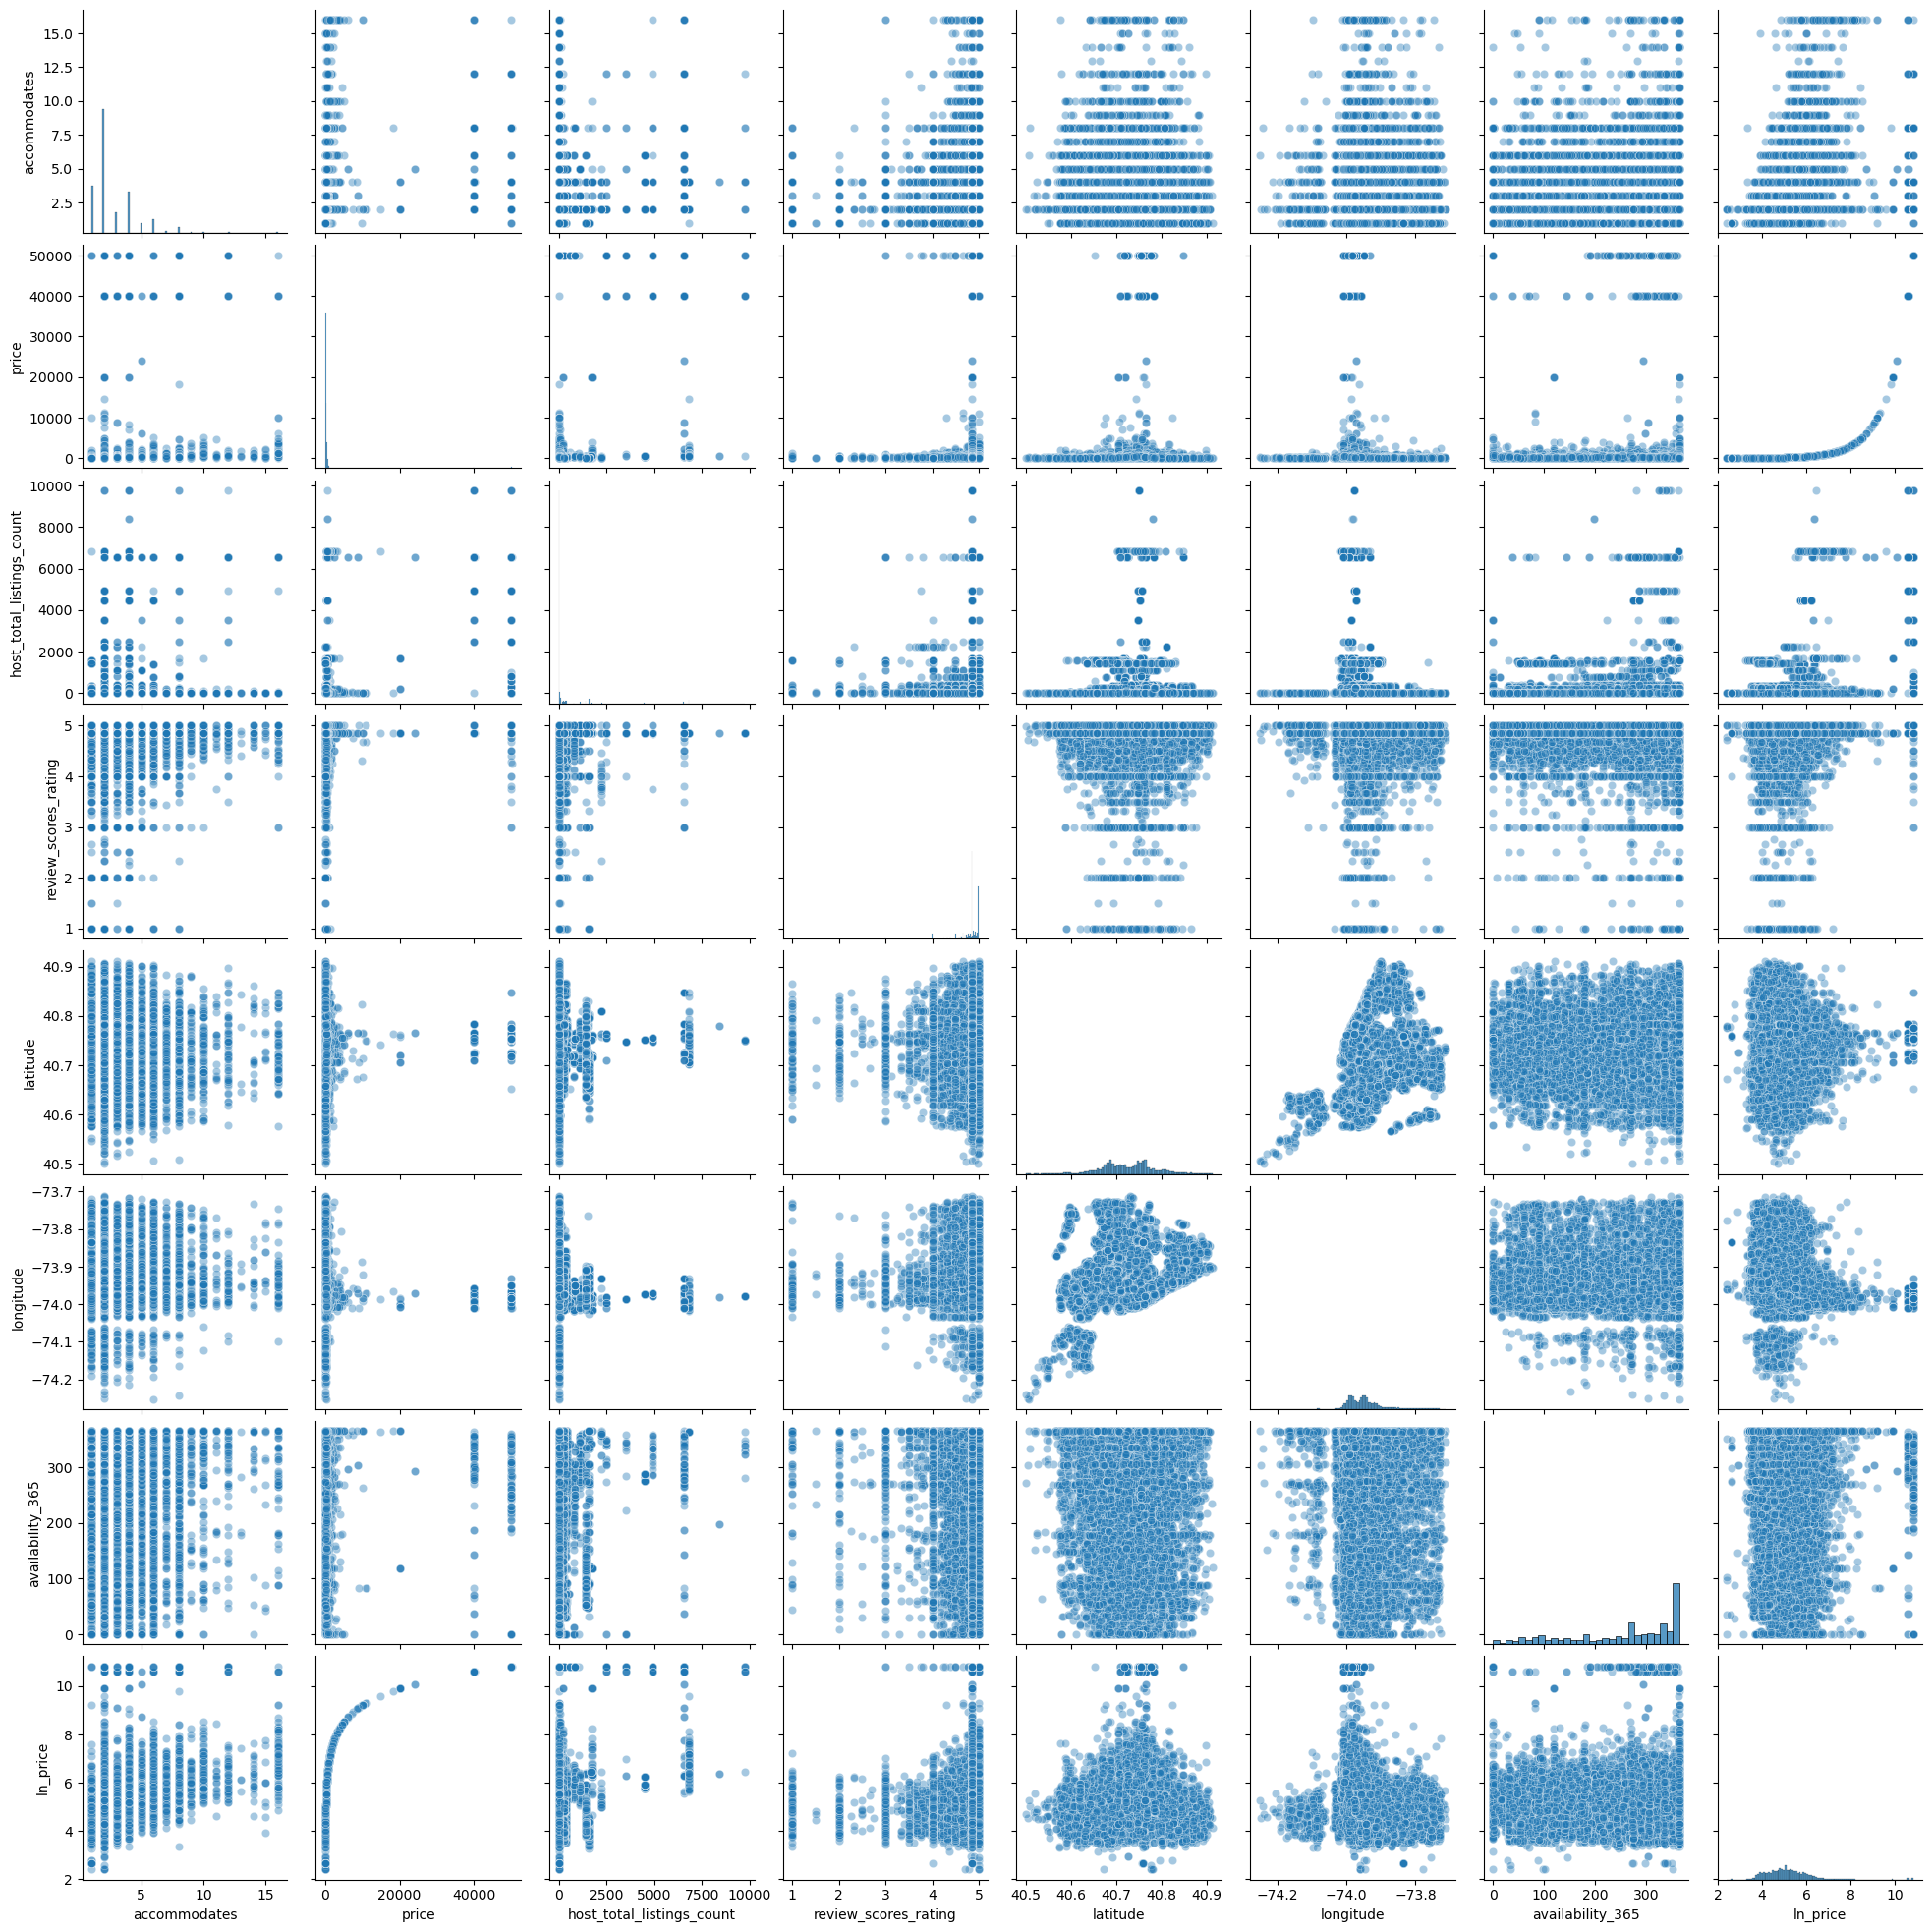

In [ ]:
sns.pairplot(df1, kind='scatter', plot_kws={'alpha':0.4})

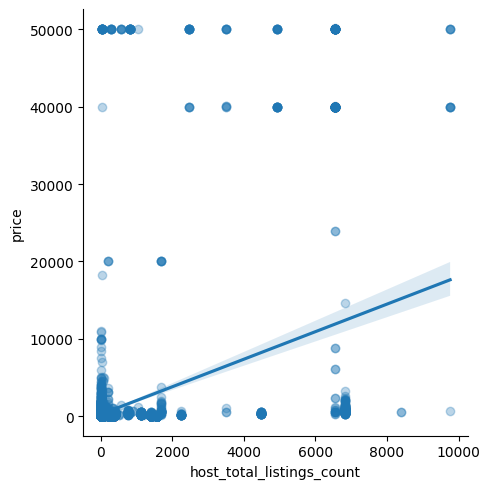

In [167]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

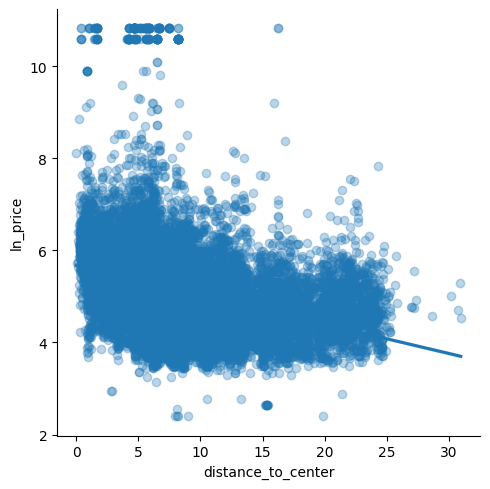

In [168]:
sns.lmplot(x = 'distance_to_center', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

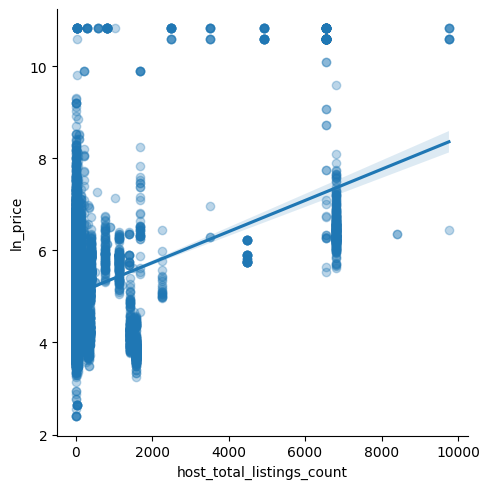

In [169]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

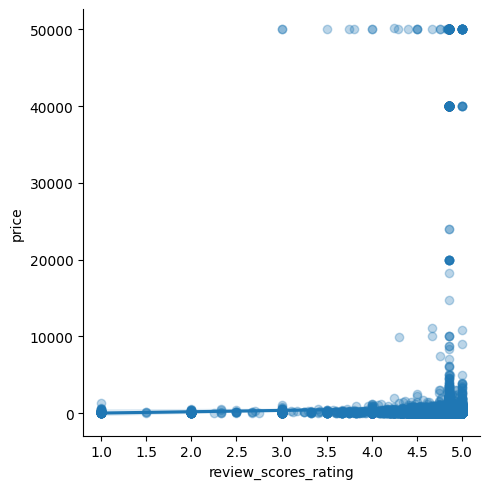

In [170]:
sns.lmplot(x = 'review_scores_rating', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

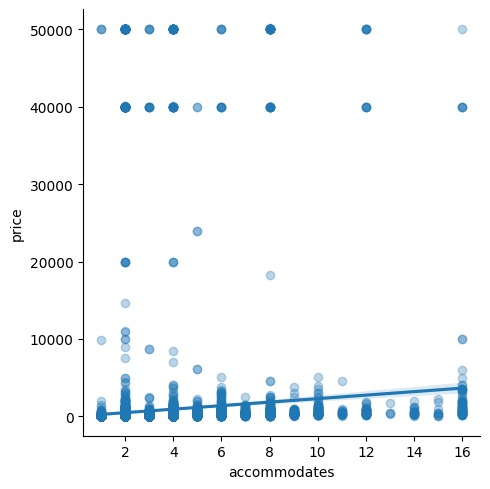

In [171]:
sns.lmplot(x = 'accommodates', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

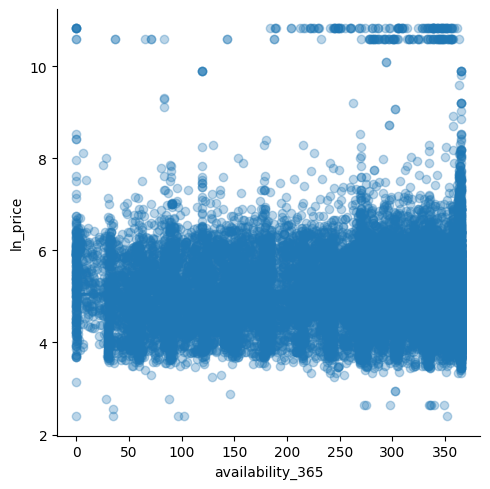

In [172]:
sns.lmplot(x = 'availability_365', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

In [173]:
from sklearn.model_selection import train_test_split

In [176]:
X = df1[['distance_to_center', 'host_total_listings_count', 'accommodates', 'availability_365', 'is_instant_bookable']]
y = df1['ln_price']

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [178]:
y_train

12857    4.727388
20012    5.683580
22927    5.062595
1178     5.129899
30404    6.723832
           ...   
24089    5.908083
24937    4.394449
15398    4.304065
1770     5.429346
29669    4.653960
Name: ln_price, Length: 14929, dtype: float64

# Training the model

In [179]:
from sklearn.linear_model import LinearRegression

In [180]:
lm = LinearRegression()

In [181]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Koeffizienten

In [182]:
lm.coef_

array([-5.03841298e-02,  3.11916514e-04,  2.12663834e-01, -9.94458972e-05,
        5.00396425e-01])

In [183]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)

                               Coef
distance_to_center        -0.050384
host_total_listings_count  0.000312
accommodates               0.212664
availability_365          -0.000099
is_instant_bookable        0.500396


### Predictions

In [184]:
predictions = lm.predict(X_test)

In [185]:
predictions

array([5.16201523, 4.83489863, 5.16119372, ..., 4.92846657, 5.24509393,
       7.38442317], shape=(6399,))

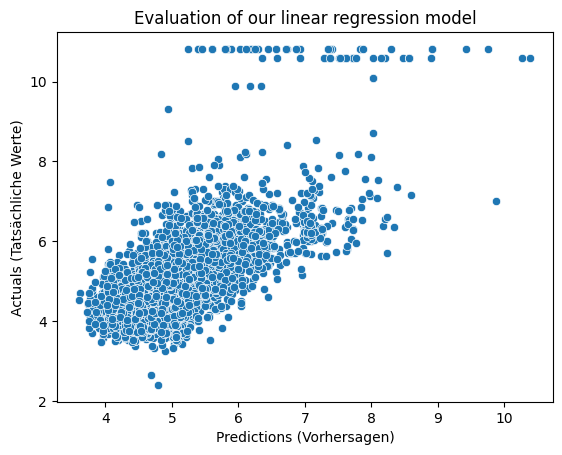

In [186]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions (Vorhersagen)")
plt.ylabel("Actuals (Tatsächliche Werte)")
plt.title("Evaluation of our linear regression model")
plt.show()

In [187]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [188]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  0.5174487406121849
Mean Squared Error:  0.5399855703608061
RMSE:  0.7348371046434754


## Ent-Transformation (wichtiger Schritt)

Um die Modellgüte korrekt zu interpretieren, müssen die Fehlerwerte aus dem logarithmierten Raum zurück in die ursprüngliche Einheit **USD** transformiert werden.

Da im Modell die natürliche Logarithmusfunktion verwendet wurde,

$$
\[
y_{\text{log}} = \ln(y),
\]
$$
erfolgt die Rücktransformation mit der **Exponentialfunktion**:
$$
\[
y = e^{y_{\text{log}}}
\]
$$
---

## Schätzung des mittleren absoluten Fehlers (MAE in USD)

Der mittlere absolute Fehler im Log-Raum (\(\text{MAE}_{\text{log}}\)) lässt sich näherungsweise in den ursprünglichen Raum transformieren durch:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{\text{MAE}_{\text{log}}} - 1
\]
$$

Setzt man den geschätzten Wert ein:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{0.59} - 1
\]
$$

$$
\[
\text{MAE}_{\text{USD}} \approx 1.80 - 1 = 0.80
\]
$$
---

## Interpretation

Das bedeutet, dass das Modell im Durchschnitt einen **relativen Fehler von etwa 80 %** aufweist.

### Beispiel

Angenommen, der wahre Preis beträgt:

\[
y = 100 \ \text{USD}
\]

Dann liegt die Modellvorhersage im Mittel in folgendem Bereich:

\[
100 \cdot (1 - 0.80) \le \hat{y} \le 100 \cdot (1 + 0.80)
\]

\[
20 \ \text{USD} \le \hat{y} \le 180 \ \text{USD}
\]

⚠️ Diese Interpretation ist **vereinfachend**, aber notwendig, um die praktische Modellgüte im ursprünglichen Maßstab zu beurteilen.


<Axes: ylabel='ln_price'>

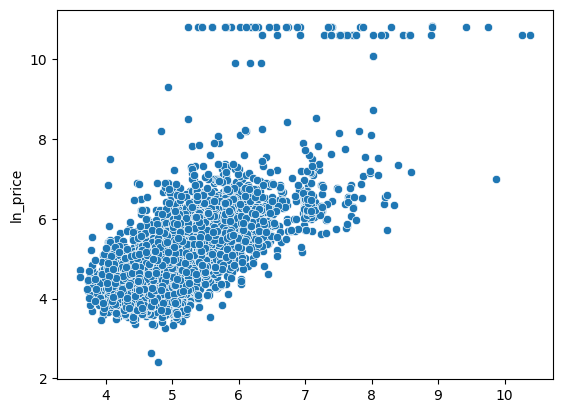

In [189]:
sns.scatterplot(x=predictions, y=y_test)

### Residuals

In [190]:
residuals = y_test - predictions
residuals

23807   -0.185281
20843    0.077756
23495   -0.248539
18970    0.483150
5481    -0.322867
           ...   
26911   -0.635478
13540   -0.611300
20965    0.478705
16030    0.494699
29538    3.212237
Name: ln_price, Length: 6399, dtype: float64

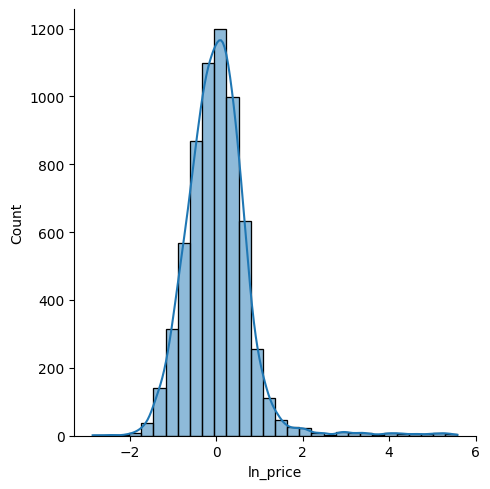

In [191]:
sns.displot(residuals, bins=30, kde=True)

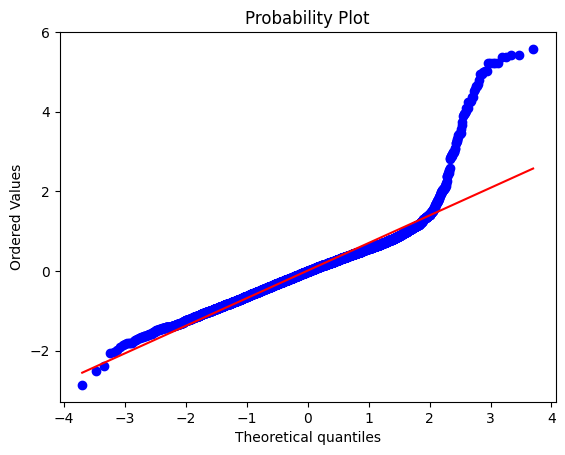

In [192]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [193]:
import numpy as np
from sklearn.metrics import r2_score

# Annahmen: 
# X_test, y_test sind Ihre Testdaten
# model ist Ihr trainiertes Regressionsmodell

# 1. Berechne den R²
y_pred = lm.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R²-Wert: {r2:.4f}")

# 2. Berechne den Adjusted R²
n = X_test.shape[0]  # Stichprobengröße (Anzahl der Testdatenpunkte)
k = X_test.shape[1]  # Anzahl der Features (Spalten)

# Adjusted R² Formel: 1 - (1 - R²) * (n - 1) / (n - k - 1)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"Adjusted R²-Wert: {adj_r2:.4f}")

R²-Wert: 0.4588
Adjusted R²-Wert: 0.4584
